# Project Assignment No. 2
Evaluate the effectiveness of various methods designed to detect outliers (anomalies).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data exploration

> Consider the Outlier Detection DataSets (ODDS) repository: https://shebuti.com/outlier-detection-datasets
odds/.
>
> Each dataset includes a class variable y, where 1 denotes outliers and 0 denotes inliers. Please review the
dataset descriptions available on the ODDS webpage. The provided anomaly labels will be treated as ground
truth. This will allow you to evaluate the performance of outlier detection algorithms using metrics such as
AUC, Accuracy, Precision, Recall, etc.
>
> Additionally, use selected 2-dimensional datasets from the Benchmark Suite for Clustering Algorithms:
https://clustering-benchmarks.gagolewski.com/weave/suite-v1.html
>
> Choose datasets that, in your opinion, are well suited for evaluating outlier/anomaly detection. This will
allow you to include a visual assessment of the performance of the investigated algorithms (in addition to
quantitative metrics).
>
> Assume that anomaly labels are not available during the training stage

### 1.1 Helper Functions

In [4]:
import urllib.request
import gzip

def load_odds_dataset(filepath):
    mat = scipy.io.loadmat(filepath)
    X = mat['X']
    y = mat['y'].ravel()
    df = pd.DataFrame(X, columns=[f"Feature_{i+1}" for i in range(X.shape[1])])
    return df, y

def load_benchmark_2d_dataset(battery, dataset, label_idx=0):
    """Load a 2D dataset from the clustering benchmark suite (v1.1.0).
    Labels: 0 = noise/anomaly, 1,2,... = cluster membership.
    Returns X (DataFrame), y_cluster (raw labels), y_anomaly (binary: 1=anomaly).
    """
    base = "https://raw.githubusercontent.com/gagolews/clustering-data-v1/v1.1.0"
    data_url = f"{base}/{battery}/{dataset}.data.gz"
    labels_url = f"{base}/{battery}/{dataset}.labels{label_idx}.gz"

    with urllib.request.urlopen(data_url) as resp:
        with gzip.open(resp) as f:
            X = np.loadtxt(f)

    with urllib.request.urlopen(labels_url) as resp:
        with gzip.open(resp) as f:
            y_cluster = np.loadtxt(f, dtype=int)

    df = pd.DataFrame(X, columns=[f"Feature_{i+1}" for i in range(X.shape[1])])
    y_anomaly = (y_cluster == 0).astype(int)
    return df, y_cluster, y_anomaly

def summarize_dataset(name, X, y_anomaly):
    n_samples, n_features = X.shape
    n_outliers = np.sum(y_anomaly == 1)
    outlier_ratio = n_outliers / n_samples * 100
    print(f"Dataset       : {name}")
    print(f"Observations  : {n_samples}")
    print(f"Features      : {n_features}")
    print(f"Anomalies     : {n_outliers} ({outlier_ratio:.2f}%)")
    print()

### 1.2 Loading Datasets

**ODDS datasets** (multi-dimensional, with ground-truth anomaly labels):
- `glass` – 214 samples × 9 features, ~4% anomalies
- `ionosphere` – 351 samples × 34 features, ~36% anomalies

**2D Benchmark datasets** (used for visual evaluation):
- `graves/ring_noisy` – 1 050 samples, ring structure with 43 scattered noise points (~4% anomalies)
- `graves/zigzag_noisy` – 300 samples, zig-zag clusters with 38 noise points (~13% anomalies)

In [ ]:
DATA_DIR = os.path.join('..', 'data', 'raw')

glass_X, glass_y       = load_odds_dataset(os.path.join(DATA_DIR, 'glass.mat'))
ionosphere_X, ionosphere_y = load_odds_dataset(os.path.join(DATA_DIR, 'ionosphere.mat'))

ring_noisy_X,   ring_noisy_yc,   ring_noisy_y   = load_benchmark_2d_dataset('graves', 'ring_noisy')
zigzag_noisy_X, zigzag_noisy_yc, zigzag_noisy_y = load_benchmark_2d_dataset('graves', 'zigzag_noisy')

print("Datasets loaded successfully.")

Datasets loaded successfully.


### 1.3 Dataset Summaries

In [6]:
datasets = {
    'glass (ODDS)':           (glass_X, glass_y),
    'ionosphere (ODDS)':      (ionosphere_X, ionosphere_y),
    'ring_noisy (2D)':        (ring_noisy_X, ring_noisy_y),
    'zigzag_noisy (2D)':      (zigzag_noisy_X, zigzag_noisy_y),
}

for name, (X, y) in datasets.items():
    summarize_dataset(name, X, y)

Dataset       : glass (ODDS)
Observations  : 214
Features      : 9
Anomalies     : 9 (4.21%)

Dataset       : ionosphere (ODDS)
Observations  : 351
Features      : 33
Anomalies     : 126 (35.90%)

Dataset       : ring_noisy (2D)
Observations  : 1050
Features      : 2
Anomalies     : 43 (4.10%)

Dataset       : zigzag_noisy (2D)
Observations  : 300
Features      : 2
Anomalies     : 38 (12.67%)



### 1.4 ODDS Dataset Visualisations

Box plots show the per-feature value distributions split by class (inlier / outlier), and the correlation heatmap reveals linear relationships between features.

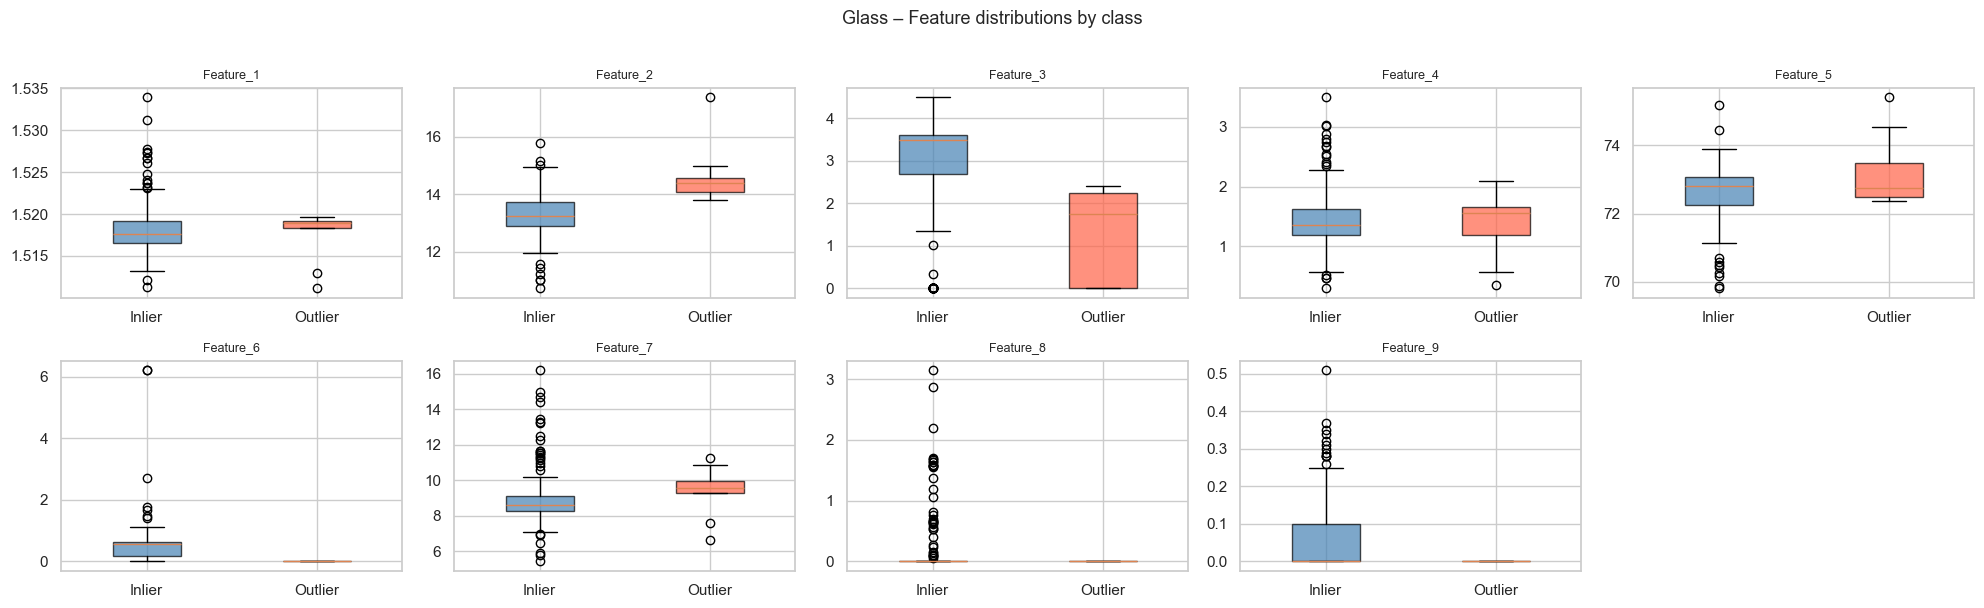

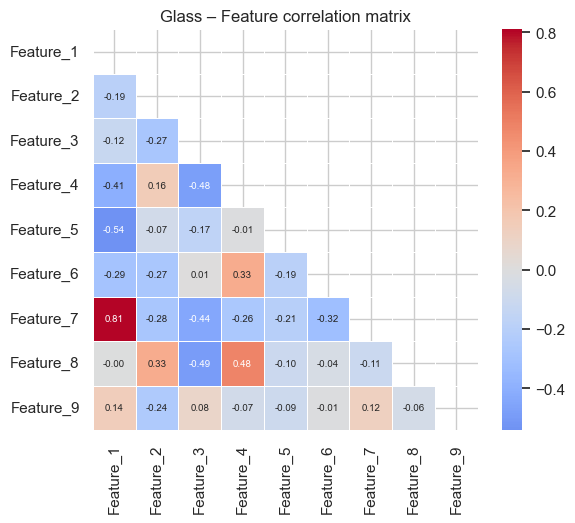

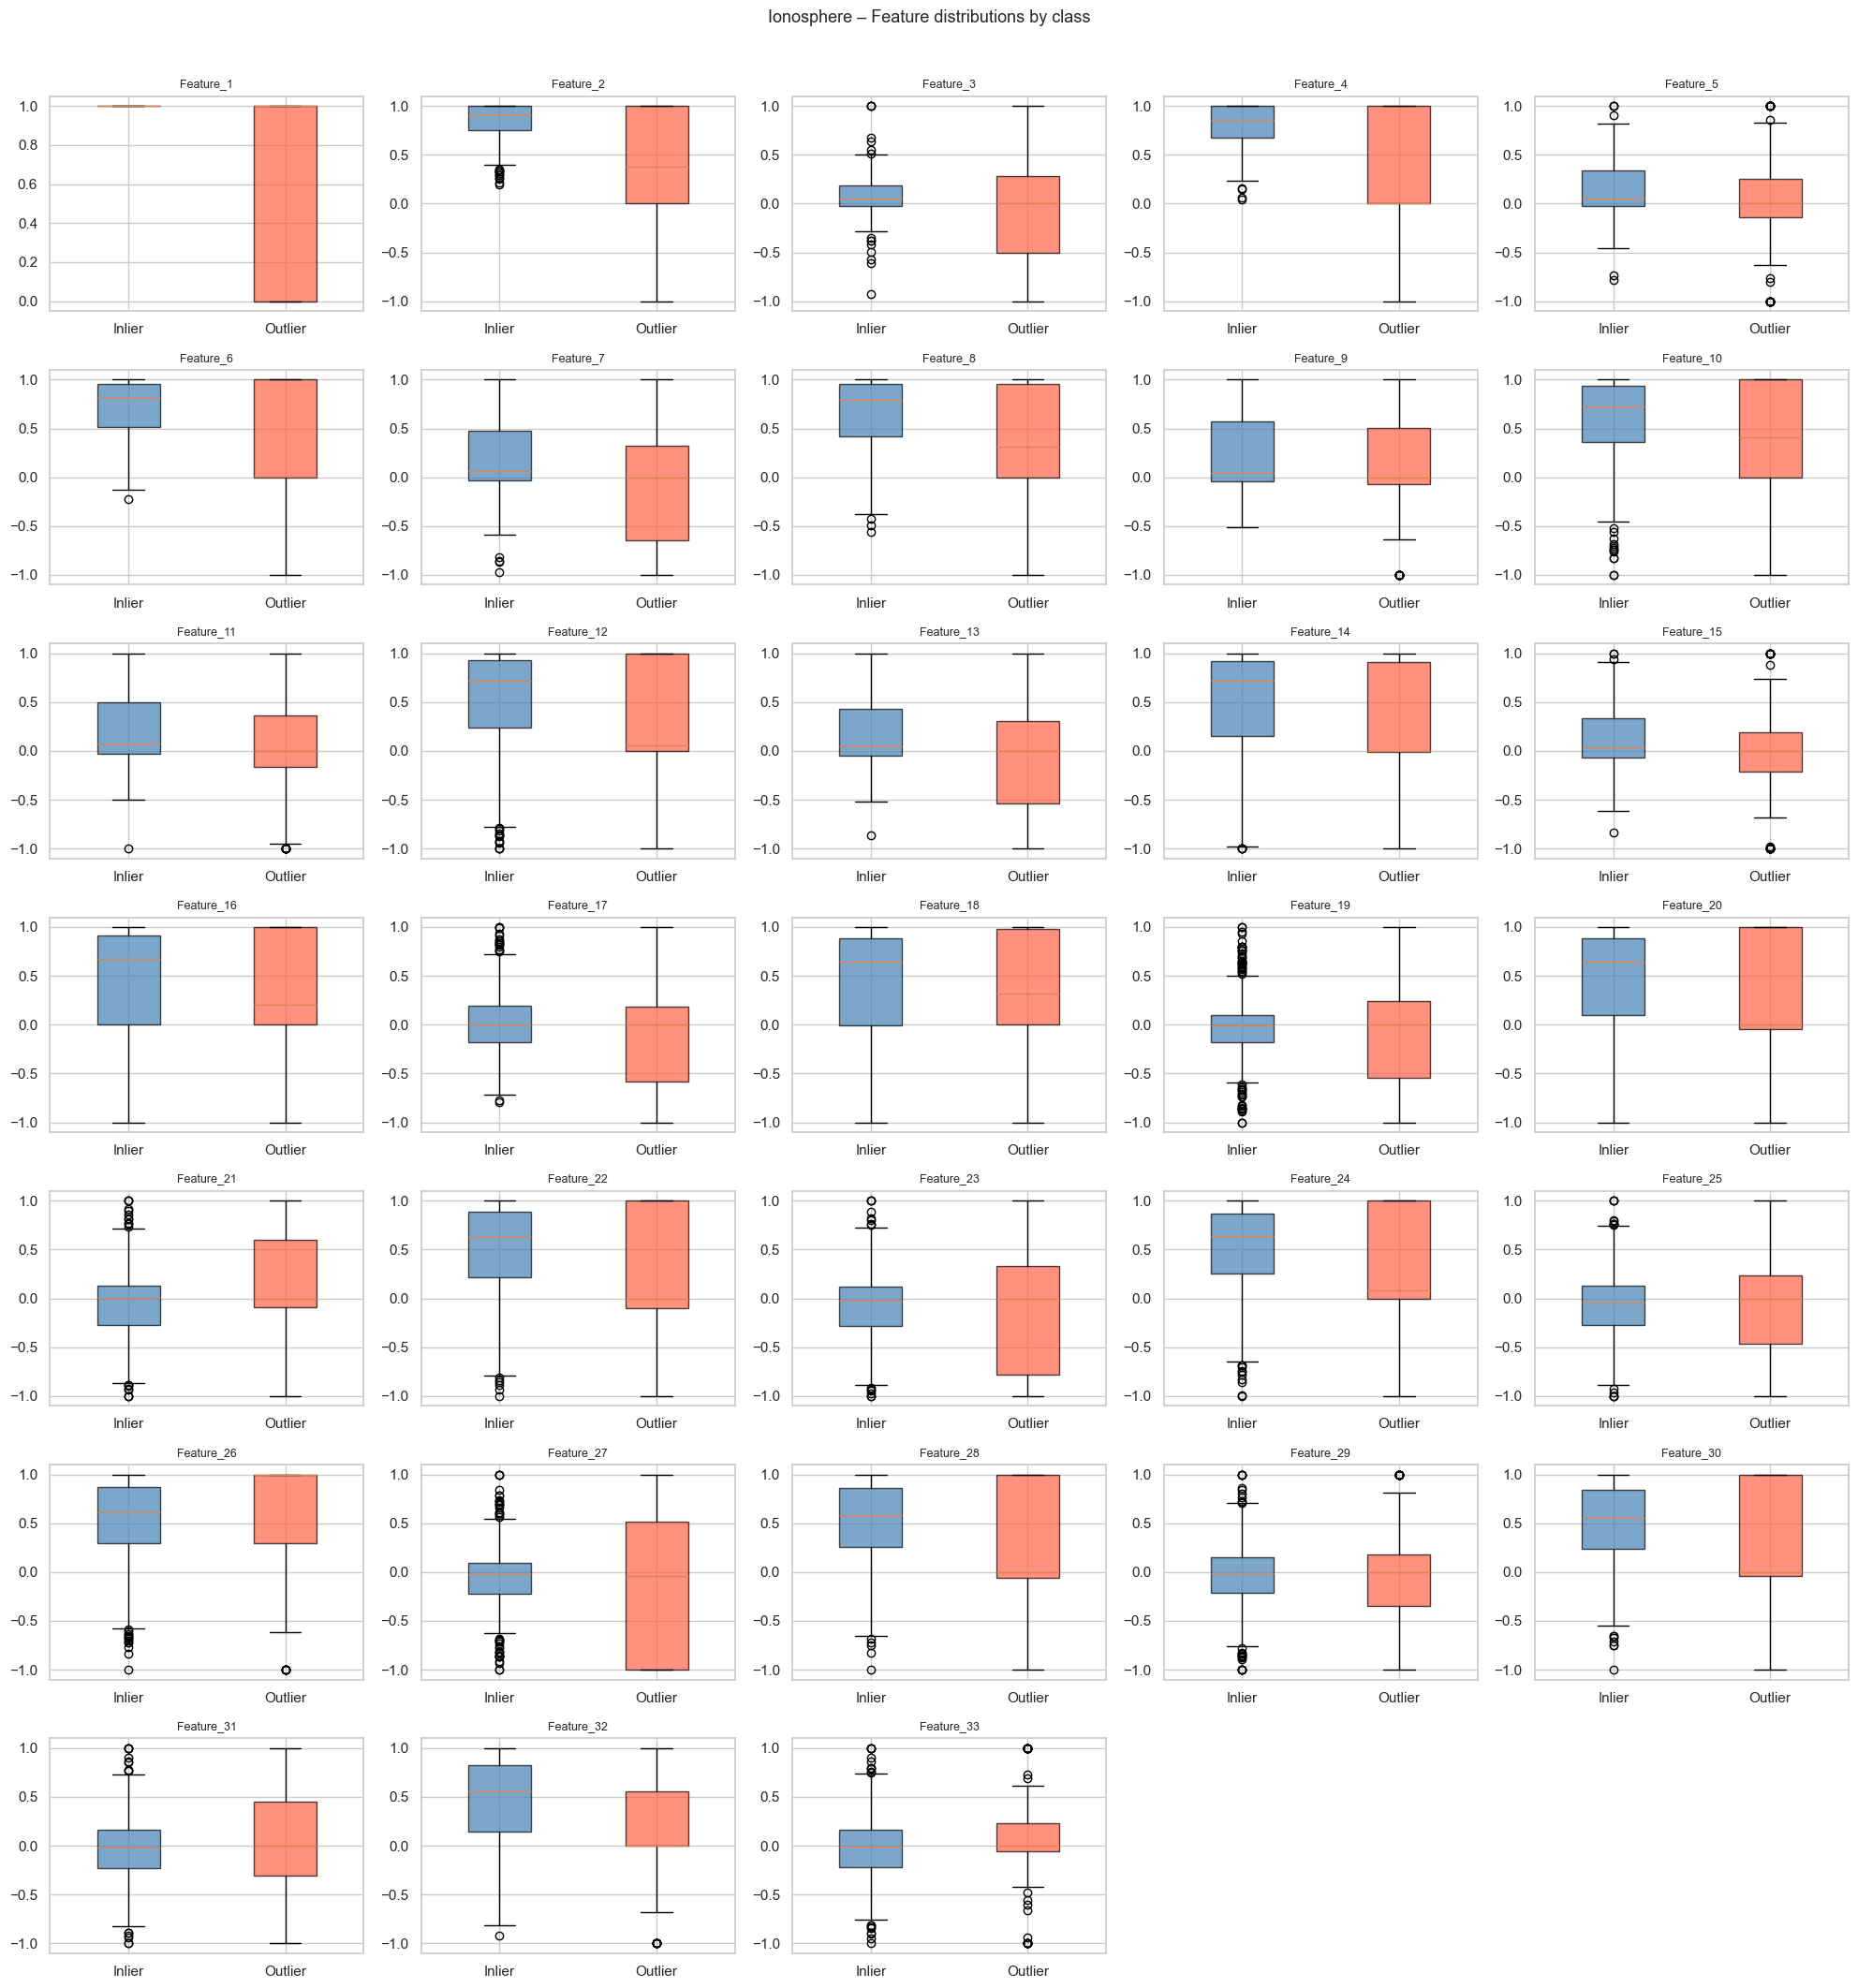

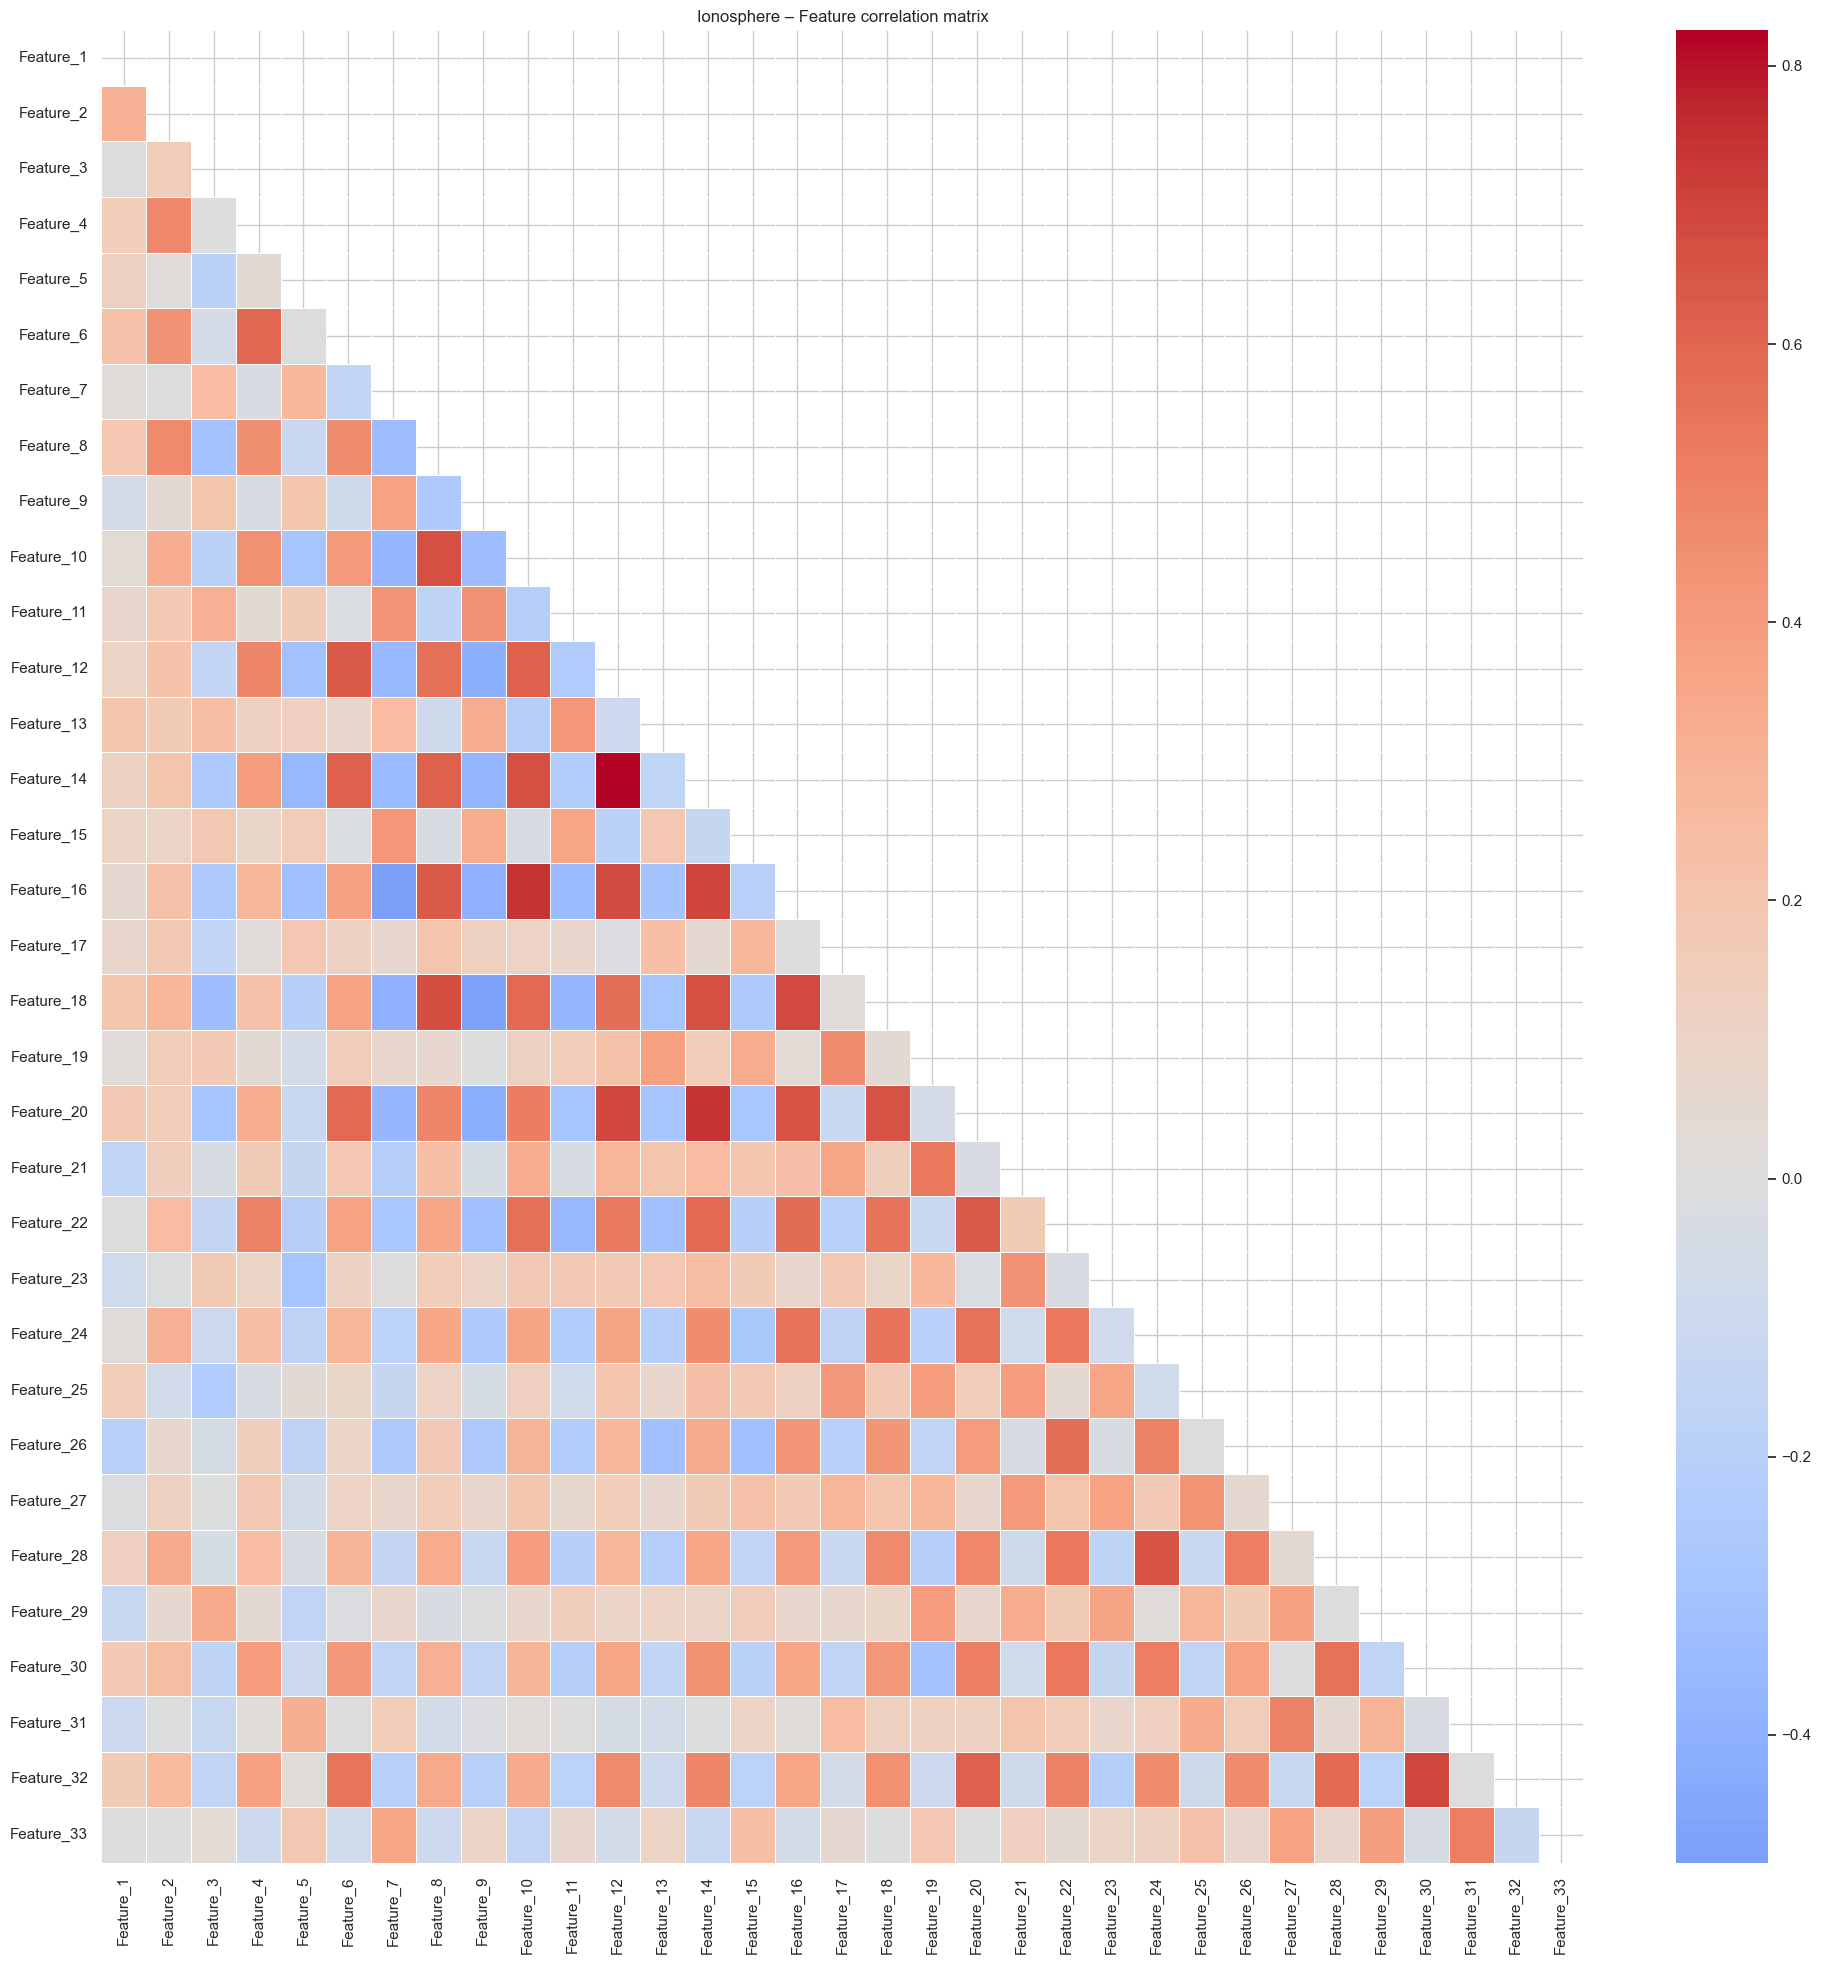

In [ ]:
def plot_odds_dataset(name, X, y):
    df = X.copy()
    df['Class'] = pd.Series(y.astype(int)).map({0: 'Inlier', 1: 'Outlier'}).values
    n_features = X.shape[1]

    n_cols = min(5, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(X.columns):
        ax = axes[i]
        for cls_idx, (cls, color) in enumerate([('Inlier', 'steelblue'), ('Outlier', 'tomato')]):
            grp = df[df['Class'] == cls][col].dropna()
            ax.boxplot(grp, positions=[cls_idx], widths=0.4, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.7))
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Inlier', 'Outlier'])
        ax.set_title(col, fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{name} – Feature distributions by class', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(max(6, n_features * 0.6), max(5, n_features * 0.6)))
    corr = X.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=(n_features <= 12), fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
                annot_kws={'size': 7})
    ax.set_title(f'{name} – Feature correlation matrix', fontsize=12)
    plt.tight_layout()
    plt.show()


for ds_name, X, y in [('Glass', glass_X, glass_y), ('Ionosphere', ionosphere_X, ionosphere_y)]:
    plot_odds_dataset(ds_name, X, y)

### 1.5 2D Benchmark Dataset Visualisations

Scatter plots coloured by the ground-truth cluster label. Noise points (label = 0, treated as anomalies) are shown in red. This allows a direct **visual assessment** of where anomaly detection algorithms should place their decision boundaries.

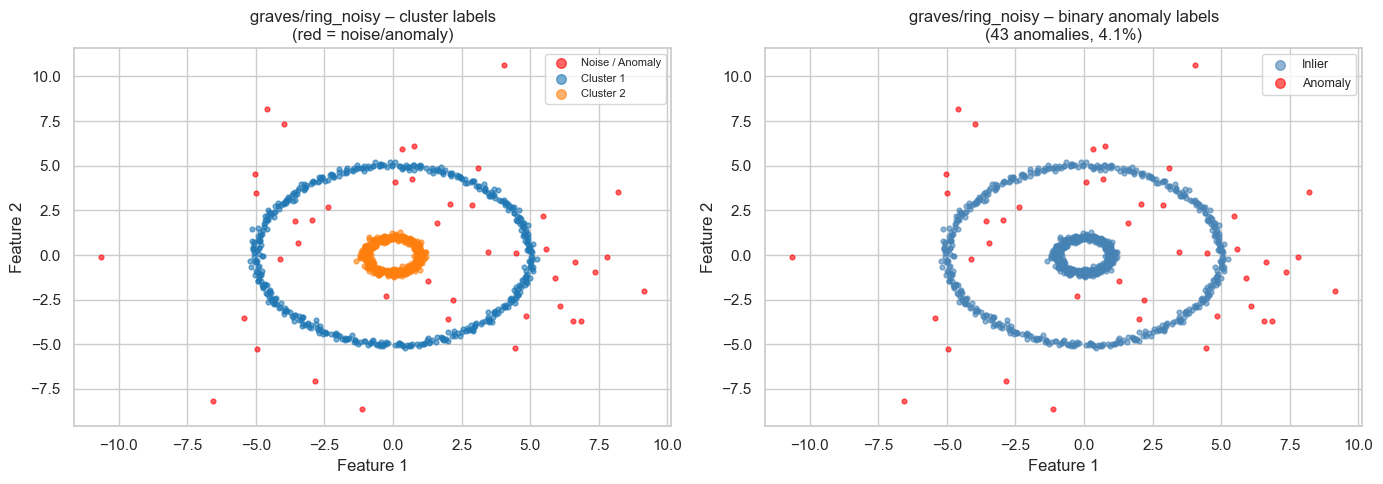

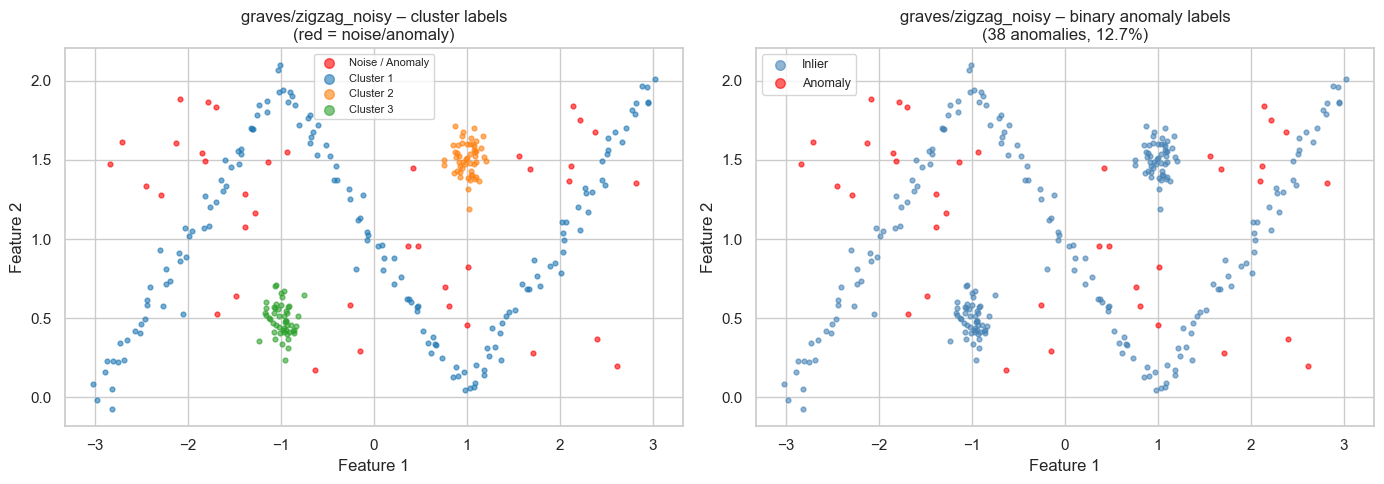

In [ ]:
def plot_2d_dataset(name, X, y_cluster, y_anomaly):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    unique_labels = np.unique(y_cluster)
    palette = plt.cm.tab10.colors
    for lbl in unique_labels:
        mask = y_cluster == lbl
        color = 'red' if lbl == 0 else palette[(lbl - 1) % len(palette)]
        label_str = 'Noise / Anomaly' if lbl == 0 else f'Cluster {lbl}'
        ax.scatter(X.iloc[mask, 0], X.iloc[mask, 1],
                   c=[color], s=12, alpha=0.6, label=label_str)
    ax.set_title(f'{name} – cluster labels\n(red = noise/anomaly)')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8, markerscale=2)

    ax = axes[1]
    for lbl, color, label_str in [(0, 'steelblue', 'Inlier'), (1, 'red', 'Anomaly')]:
        mask = y_anomaly == lbl
        ax.scatter(X.iloc[mask, 0], X.iloc[mask, 1],
                   c=[color], s=12, alpha=0.6, label=label_str)
    n_anomaly = y_anomaly.sum()
    ratio = n_anomaly / len(y_anomaly) * 100
    ax.set_title(f'{name} – binary anomaly labels\n({n_anomaly} anomalies, {ratio:.1f}%)')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=9, markerscale=2)

    plt.tight_layout()
    plt.show()


datasets_2d = [
    ('graves/ring_noisy',   ring_noisy_X,   ring_noisy_yc,   ring_noisy_y),
    ('graves/zigzag_noisy', zigzag_noisy_X, zigzag_noisy_yc, zigzag_noisy_y),
]

for ds_name, X, yc, ya in datasets_2d:
    plot_2d_dataset(ds_name, X, yc, ya)

---

## 2. Algorithms

We evaluate five unsupervised anomaly detection methods:

| Method | Key idea |
|---|---|
| **One-Class SVM** | Learns a hypersphere/hyperplane boundary around inliers in feature space |
| **Isolation Forest** | Randomly partitions data; anomalies are isolated in fewer splits |
| **Local Outlier Factor** | Compares local density of a point to its neighbours |
| **DBSCAN** | Density-based clustering; points not belonging to any cluster are anomalies |
| **Elliptic Envelope** | Fits a robust Gaussian ellipsoid; outliers lie beyond the Mahalanobis distance threshold |

**Training assumption**: anomaly labels are **not** used during fitting. A fixed `contamination=0.1` is used as the default prior for all methods that require it.

### 2.1 Setup

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              precision_score, recall_score, f1_score)

CONTAMINATION = 0.1
RANDOM_STATE  = 42

ALL_DATASETS = {
    'Glass':         (glass_X,         glass_y),
    'Ionosphere':    (ionosphere_X,     ionosphere_y),
    'ring_noisy':    (ring_noisy_X,     ring_noisy_y),
    'zigzag_noisy':  (zigzag_noisy_X,   zigzag_noisy_y),
}

def compute_metrics(y_true, y_pred, y_score=None):
    metrics = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        try:
            metrics['AUC'] = roc_auc_score(y_true, y_score)
        except Exception:
            metrics['AUC'] = float('nan')
    else:
        metrics['AUC'] = float('nan')
    return metrics

def run_methods(X, y_true, contamination=CONTAMINATION):
    Xs = StandardScaler().fit_transform(X)
    results = {}

    # 1. One-Class SVM
    ocsvm = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
    pred  = (ocsvm.fit_predict(Xs) == -1).astype(int)
    score = -ocsvm.decision_function(Xs)          # higher = more anomalous
    results['One-Class SVM'] = compute_metrics(y_true, pred, score)

    # 2. Isolation Forest
    iforest = IsolationForest(contamination=contamination,
                               n_estimators=100, random_state=RANDOM_STATE)
    pred  = (iforest.fit_predict(Xs) == -1).astype(int)
    score = -iforest.decision_function(Xs)
    results['Isolation Forest'] = compute_metrics(y_true, pred, score)

    # 3. Local Outlier Factor
    lof  = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
    pred = (lof.fit_predict(Xs) == -1).astype(int)
    score = -lof.negative_outlier_factor_
    results['LOF'] = compute_metrics(y_true, pred, score)

    # 4. DBSCAN  (eps tuned via 4-NN distance 95th percentile)
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=4).fit(Xs)
    dists, _ = nn.kneighbors(Xs)
    eps = np.percentile(dists[:, -1], 95)
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(Xs)
    pred   = (labels == -1).astype(int)
    results['DBSCAN'] = compute_metrics(y_true, pred)       # no AUC score

    # 5. Elliptic Envelope
    ee   = EllipticEnvelope(contamination=contamination, random_state=RANDOM_STATE)
    pred = (ee.fit_predict(Xs) == -1).astype(int)
    score = -ee.decision_function(Xs).ravel()
    results['Elliptic Envelope'] = compute_metrics(y_true, pred, score)

    return results

### 2.2 Performance Evaluation

Each method is fitted without using ground-truth labels (`contamination=0.1` as default prior). Performance is measured against the known ground truth.

In [ ]:
all_results = {}
for ds_name, (X, y) in ALL_DATASETS.items():
    all_results[ds_name] = run_methods(X, y)

# Build a multi-index DataFrame
records = []
for ds_name, method_dict in all_results.items():
    for method, metrics in method_dict.items():
        records.append({'Dataset': ds_name, 'Method': method, **metrics})

results_df = pd.DataFrame(records).set_index(['Dataset', 'Method'])

metrics_order = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
results_df = results_df[metrics_order]

styled = (results_df.style
    .format('{:.3f}', na_rep='—')
    .background_gradient(cmap='RdYlGn', axis=0, subset=metrics_order)
    .set_caption('Table 1 – Performance metrics (contamination=0.1, default hyperparameters)'))
styled

C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-30.229495937618022 > -94.444996443514924). You may want to try with a higher value of support_fraction (current value: 0.523).
  warnings.warn(
C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-30.316918932478206 > -94.462242864668752). You may want to try with a higher value of support_fraction (current value: 0.523).
  warnings.warn(
C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-30.298770812107538 > -94.432460979564354). You may want to try with a higher value of support_

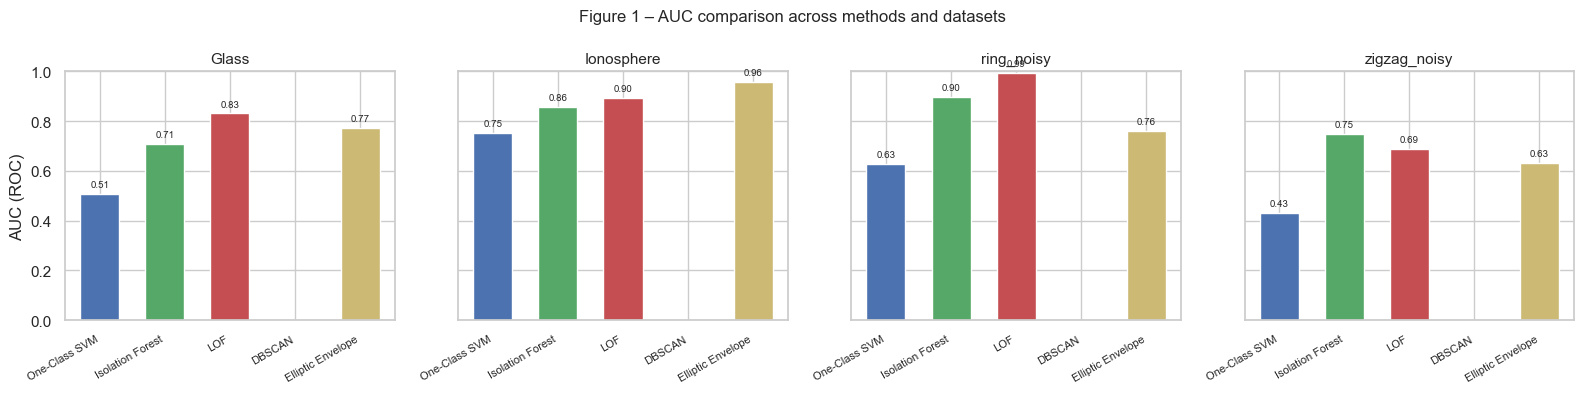

In [ ]:
methods_order = ['One-Class SVM', 'Isolation Forest', 'LOF', 'DBSCAN', 'Elliptic Envelope']
plot_metric = 'AUC'

fig, axes = plt.subplots(1, len(ALL_DATASETS), figsize=(16, 4), sharey=True)
for ax, (ds_name, _) in zip(axes, ALL_DATASETS.items()):
    vals = [results_df.loc[(ds_name, m), plot_metric] for m in methods_order]
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
    bars = ax.bar(methods_order, vals, color=colors, edgecolor='white', width=0.6)
    ax.set_title(ds_name, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(methods_order)))
    ax.set_xticklabels(methods_order, rotation=30, ha='right', fontsize=8)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=7)

axes[0].set_ylabel('AUC (ROC)')
fig.suptitle('Figure 1 – AUC comparison across methods and datasets', fontsize=12)
plt.tight_layout()
plt.show()

### 2.3 Hyperparameter Analysis

For each method we vary its most important hyperparameters and observe the effect on AUC and F1 across all datasets.  A helper function plots line charts - one line per dataset.

In [24]:
def plot_hyperparam(param_name, param_values, metric_dict, title, xlabel=None, xscale='linear'):
    """metric_dict: {dataset_name: {param_value: {metric: value}}}"""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = plt.cm.tab10.colors

    for ax, metric in zip(axes, ['AUC', 'F1']):
        for idx, (ds_name, pv_dict) in enumerate(metric_dict.items()):
            vals = [pv_dict[v].get(metric, float('nan')) for v in param_values]
            ax.plot(param_values, vals, marker='o', label=ds_name,
                    color=colors[idx], linewidth=1.8)
        ax.set_title(f'{metric}')
        ax.set_xlabel(xlabel or param_name)
        ax.set_ylim(0, 1)
        ax.set_xscale(xscale)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.4)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

#### 2.3.1 One-Class SVM

Key hyperparameters: **`nu`** (upper bound on the fraction of outliers / margin errors), **`kernel`** type, and **`gamma`** (RBF bandwidth).

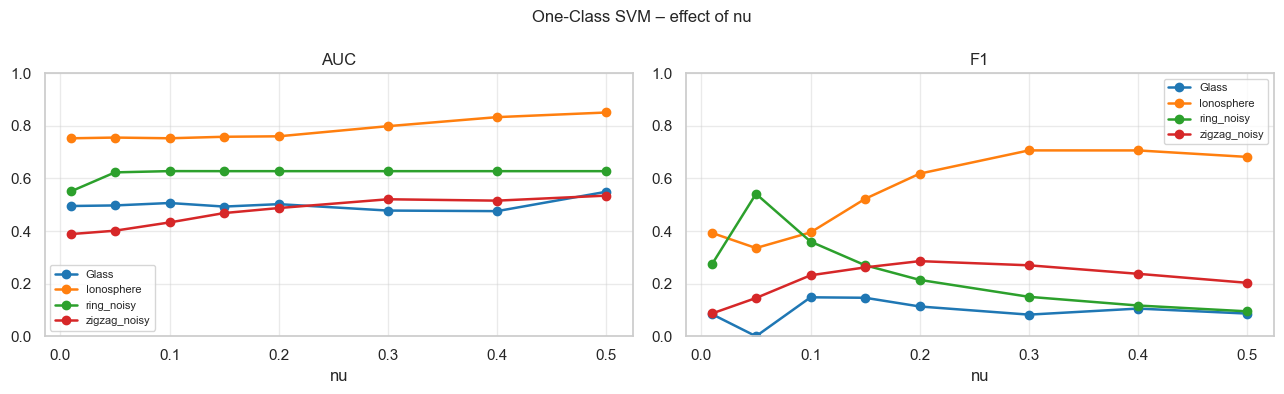

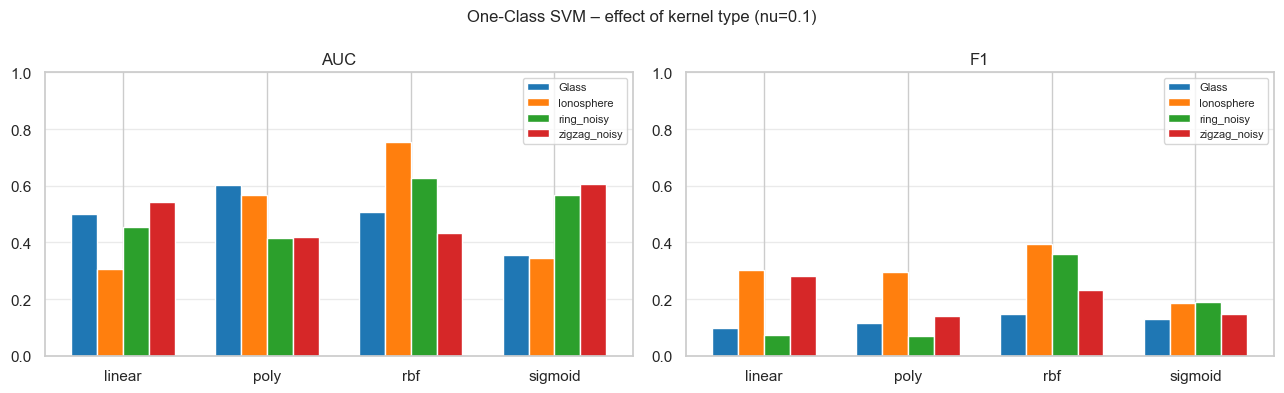

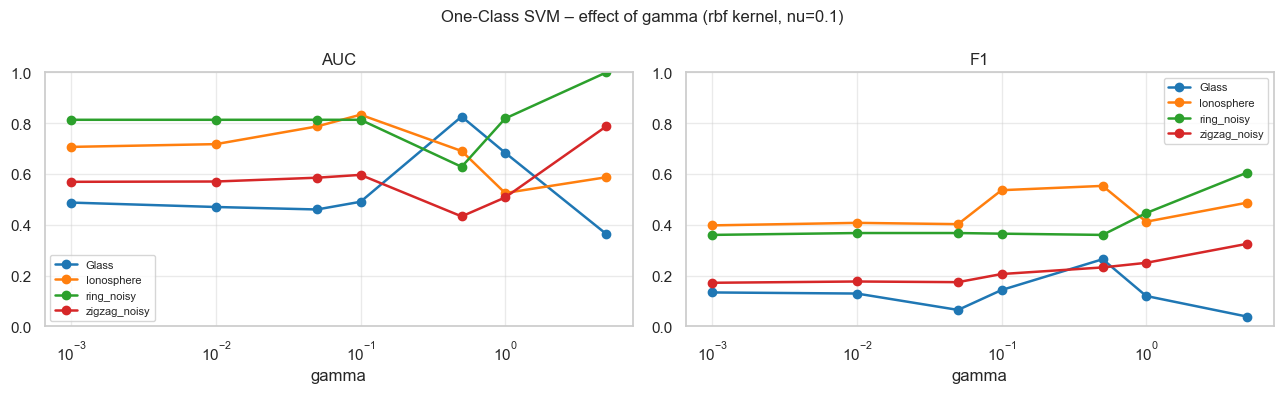

In [25]:
nu_values = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
nu_results = {}
for ds_name, (X, y) in ALL_DATASETS.items():
    Xs = StandardScaler().fit_transform(X)
    nu_results[ds_name] = {}
    for nu in nu_values:
        clf = OneClassSVM(nu=nu, kernel='rbf', gamma='scale')
        pred  = (clf.fit_predict(Xs) == -1).astype(int)
        score = -clf.decision_function(Xs)
        nu_results[ds_name][nu] = compute_metrics(y, pred, score)

plot_hyperparam('nu', nu_values, nu_results,
                title='One-Class SVM – effect of nu', xlabel='nu')

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = {}
for ds_name, (X, y) in ALL_DATASETS.items():
    Xs = StandardScaler().fit_transform(X)
    kernel_results[ds_name] = {}
    for k in kernels:
        clf  = OneClassSVM(nu=0.1, kernel=k, gamma='scale')
        pred  = (clf.fit_predict(Xs) == -1).astype(int)
        score = -clf.decision_function(Xs)
        kernel_results[ds_name][k] = compute_metrics(y, pred, score)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = plt.cm.tab10.colors
x = np.arange(len(kernels))
width = 0.18
for ax, metric in zip(axes, ['AUC', 'F1']):
    for idx, (ds_name, kdict) in enumerate(kernel_results.items()):
        vals = [kdict[k].get(metric, float('nan')) for k in kernels]
        ax.bar(x + idx * width, vals, width=width, label=ds_name, color=colors[idx])
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(kernels)
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4, axis='y')
fig.suptitle('One-Class SVM – effect of kernel type (nu=0.1)', fontsize=12)
plt.tight_layout()
plt.show()

gamma_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
gamma_results = {}
for ds_name, (X, y) in ALL_DATASETS.items():
    Xs = StandardScaler().fit_transform(X)
    gamma_results[ds_name] = {}
    for g in gamma_values:
        clf   = OneClassSVM(nu=0.1, kernel='rbf', gamma=g)
        pred  = (clf.fit_predict(Xs) == -1).astype(int)
        score = -clf.decision_function(Xs)
        gamma_results[ds_name][g] = compute_metrics(y, pred, score)

plot_hyperparam('gamma', gamma_values, gamma_results,
                title='One-Class SVM – effect of gamma (rbf kernel, nu=0.1)',
                xlabel='gamma', xscale='log')

#### 2.3.2 Isolation Forest

Key hyperparameters: **`contamination`** (expected fraction of anomalies) and **`n_estimators`** (number of isolation trees).

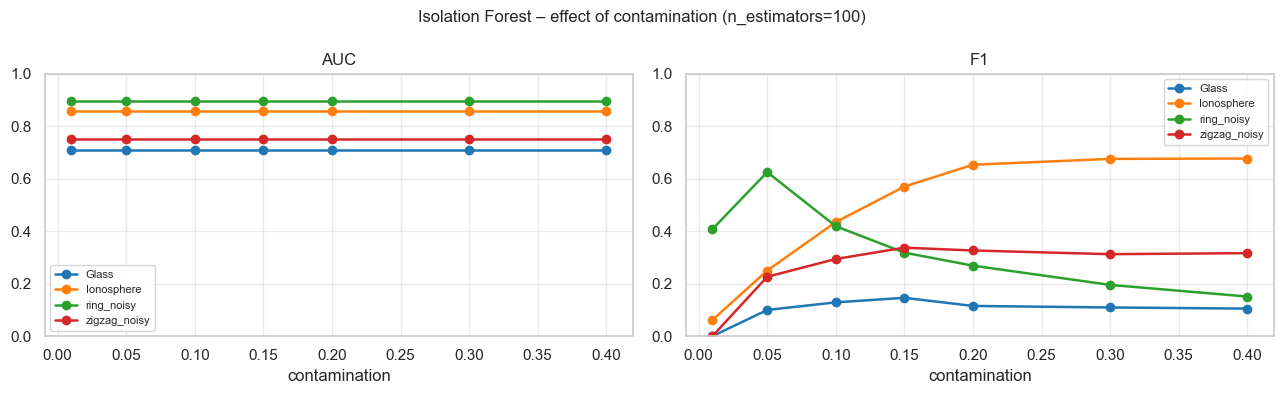

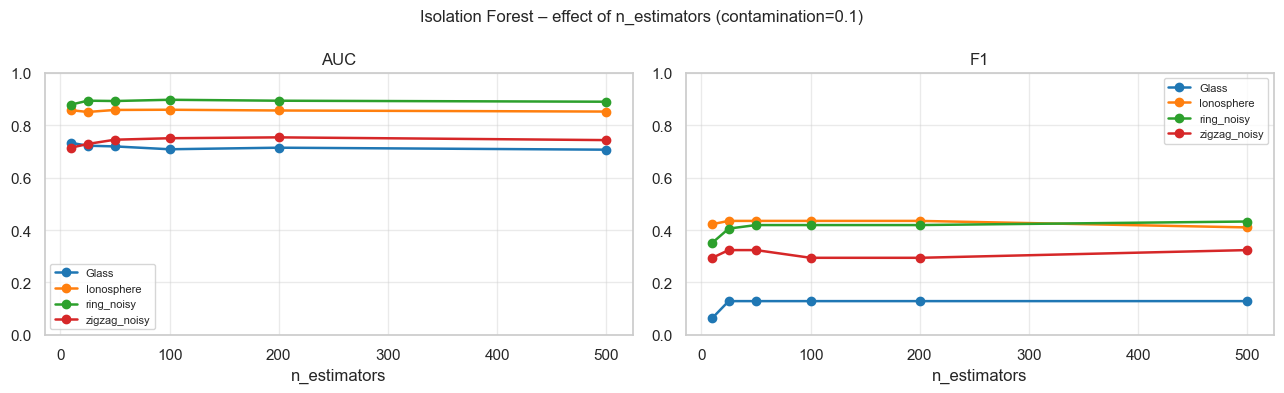

In [26]:
contamination_values = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

cont_results = {}
for ds_name, (X, y) in ALL_DATASETS.items():
    Xs = StandardScaler().fit_transform(X)
    cont_results[ds_name] = {}
    for c in contamination_values:
        clf   = IsolationForest(contamination=c, n_estimators=100, random_state=RANDOM_STATE)
        pred  = (clf.fit_predict(Xs) == -1).astype(int)
        score = -clf.decision_function(Xs)
        cont_results[ds_name][c] = compute_metrics(y, pred, score)

plot_hyperparam('contamination', contamination_values, cont_results,
                title='Isolation Forest – effect of contamination (n_estimators=100)',
                xlabel='contamination')

n_est_values = [10, 25, 50, 100, 200, 500]
nest_results = {}
for ds_name, (X, y) in ALL_DATASETS.items():
    Xs = StandardScaler().fit_transform(X)
    nest_results[ds_name] = {}
    for n in n_est_values:
        clf   = IsolationForest(contamination=0.1, n_estimators=n, random_state=RANDOM_STATE)
        pred  = (clf.fit_predict(Xs) == -1).astype(int)
        score = -clf.decision_function(Xs)
        nest_results[ds_name][n] = compute_metrics(y, pred, score)

plot_hyperparam('n_estimators', n_est_values, nest_results,
                title='Isolation Forest – effect of n_estimators (contamination=0.1)',
                xlabel='n_estimators')

#### 2.3.3 Local Outlier Factor

Key hyperparameter: **`n_neighbors`** - the size of the local neighbourhood used for density estimation.

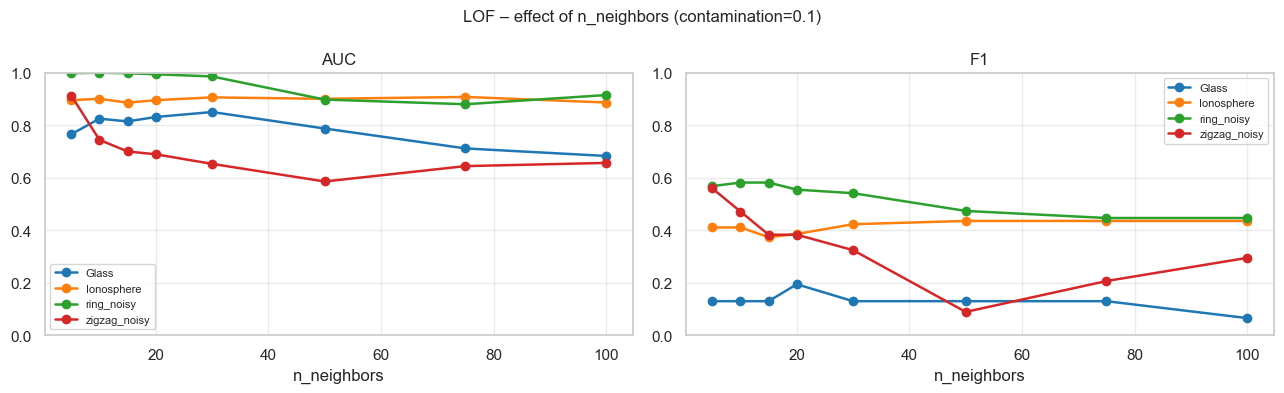

In [27]:
k_values = [5, 10, 15, 20, 30, 50, 75, 100]
lof_k_results = {}
for ds_name, (X, y) in ALL_DATASETS.items():
    Xs = StandardScaler().fit_transform(X)
    lof_k_results[ds_name] = {}
    for k in k_values:
        clf   = LocalOutlierFactor(n_neighbors=k, contamination=0.1)
        pred  = (clf.fit_predict(Xs) == -1).astype(int)
        score = -clf.negative_outlier_factor_
        lof_k_results[ds_name][k] = compute_metrics(y, pred, score)

plot_hyperparam('n_neighbors', k_values, lof_k_results,
                title='LOF – effect of n_neighbors (contamination=0.1)',
                xlabel='n_neighbors')